Experiment No.8

In [23]:
# Import libraries required for data analysis, preprocessing, classification and evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [24]:
# Load the headerless Iris dataset and assign meaningful column names

file_path = r"C:\Users\sumed\Downloads\iris.csv"
df = pd.read_csv(file_path)

print("Original dataset shape:", df.shape)
print("\nOriginal columns:")
print(df.columns.tolist())

print("Iris dataset loaded successfully.")

Original dataset shape: (150, 5)

Original columns:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Iris dataset loaded successfully.


In [26]:
# 3. CLEAN COLUMN NAMES

df.columns = df.columns.str.strip()

In [27]:
# Display the first five records of the dataset

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
# Display information about columns, data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   SepalLength  151 non-null    object
 1   SepalWidth   151 non-null    object
 2   PetalLength  151 non-null    object
 3   PetalWidth   151 non-null    object
 4   Species      151 non-null    object
dtypes: object(5)
memory usage: 6.0+ KB


In [28]:
# Generate descriptive statistics for numerical features

df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [29]:
# Check for missing values in the dataset

print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Total missing values: 0


In [30]:
# Display the column names of the dataset

print("Column names:")
print(df.columns.tolist())

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [32]:
# Count the number of samples belonging to each flower species

class_counts = df["species"].value_counts()

print("Number of samples in each species:")
print(class_counts)

Number of samples in each species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [36]:
# Separate input features and target variable

X = df[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
]

y = df["species"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget variable:", y.name)

Input features:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Target variable: species


In [37]:
# Convert categorical species labels into numerical class labels

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")
print(np.unique(y_encoded))

Original classes:
['setosa' 'versicolor' 'virginica']

Encoded classes:
[0 1 2]


In [38]:
# Display original species labels and their encoded values

encoded_data = pd.DataFrame({
    "Original Species": y,
    "Encoded Class": y_encoded
})

encoded_data.head(10)

,Original Species,Encoded Class
0,setosa,0
1,setosa,0
2,setosa,0
3,setosa,0
4,setosa,0
5,setosa,0
6,setosa,0
7,setosa,0
8,setosa,0
9,setosa,0


DATA VISUALIZATION

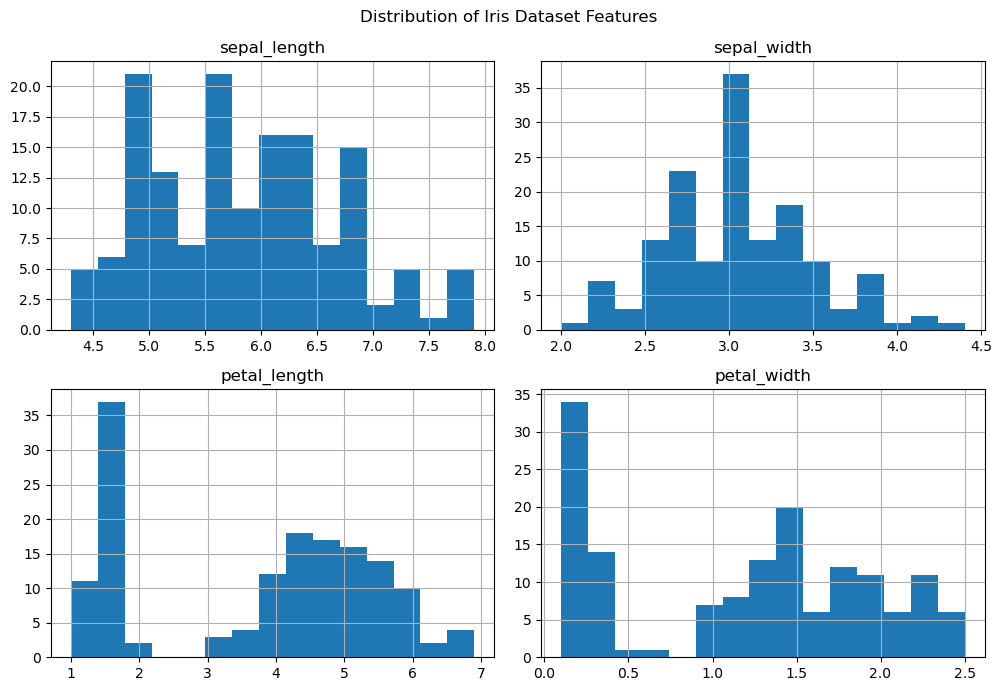

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

# Convert object columns to numeric
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Plot histograms
df[cols].hist(
    figsize=(10, 7),
    bins=15
)

plt.suptitle("Distribution of Iris Dataset Features")
plt.tight_layout()
plt.show()

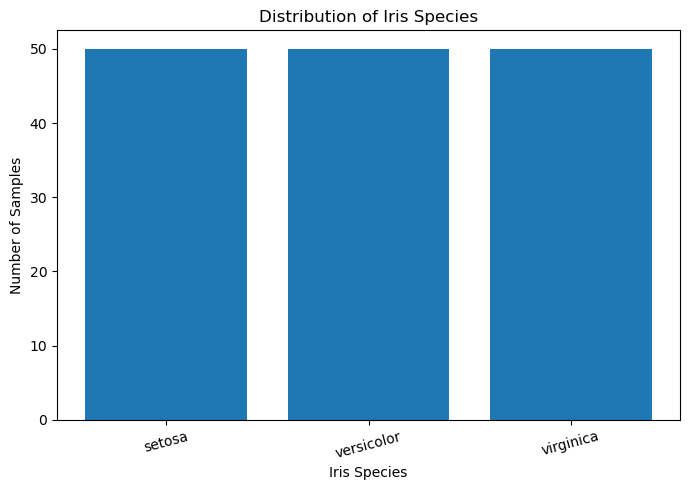

In [40]:
# Visualize the number of samples in each species

plt.figure(figsize=(7, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.xlabel("Iris Species")
plt.ylabel("Number of Samples")
plt.title("Distribution of Iris Species")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [41]:
# Remove rows containing non-numeric values
X = X.apply(pd.to_numeric, errors="coerce")

# Remove rows that became NaN
X = X.dropna()

# Calculate correlation
correlation_matrix = X.corr()

print("Feature Correlation Matrix:")
display(correlation_matrix)

Feature Correlation Matrix:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


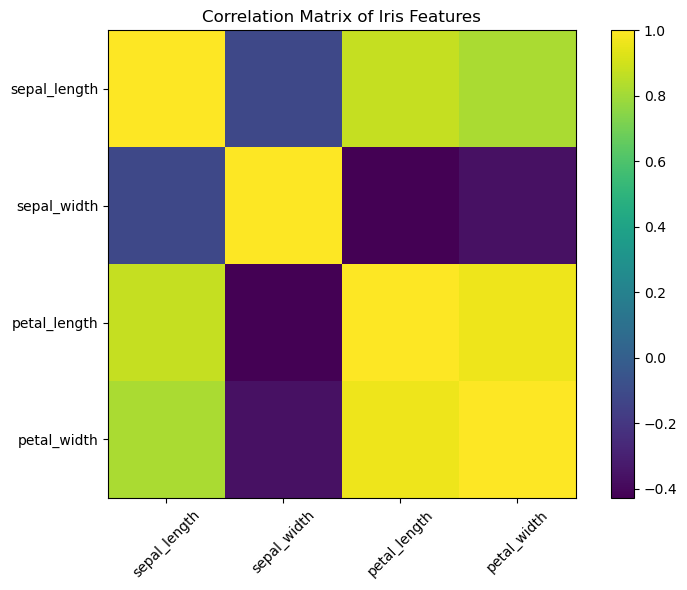

In [42]:
# Visualize the correlation matrix of Iris features

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Iris Features")

plt.tight_layout()
plt.show()

TRAIN-TEST SPLIT

In [43]:
# Split the dataset into training and testing subsets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [44]:
# Standardize feature values for scale-sensitive classification algorithms

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


CLASSIFICATION MODELS

In [45]:
# Create the Logistic Regression classifier

logistic_model = LogisticRegression(
    max_iter=200
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [46]:
# Train the Logistic Regression classifier and record training time

start_time = time.time()

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_training_time = time.time() - start_time

print("Logistic Regression training completed.")
print("Training time:", round(logistic_training_time, 4), "seconds")

Logistic Regression training completed.
Training time: 0.0269 seconds


In [47]:
# Generate predictions using Logistic Regression

logistic_pred = logistic_model.predict(X_test_scaled)

print("Logistic Regression predictions generated.")
print("First 10 predictions:", logistic_pred[:10])

Logistic Regression predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


In [48]:
# Create the Decision Tree classifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

print("Decision Tree model created.")

Decision Tree model created.


In [49]:
# Train the Decision Tree classifier

start_time = time.time()

decision_tree_model.fit(
    X_train,
    y_train
)

decision_tree_training_time = time.time() - start_time

print("Decision Tree training completed.")
print("Training time:", round(decision_tree_training_time, 4), "seconds")

Decision Tree training completed.
Training time: 0.0051 seconds


In [50]:
# Generate predictions using Decision Tree

decision_tree_pred = decision_tree_model.predict(X_test)

print("Decision Tree predictions generated.")
print("First 10 predictions:", decision_tree_pred[:10])

Decision Tree predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


In [51]:
# Create the Random Forest classifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created.")

Random Forest model created.


In [52]:
# Train the Random Forest classifier

start_time = time.time()

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_training_time = time.time() - start_time

print("Random Forest training completed.")
print("Training time:", round(random_forest_training_time, 4), "seconds")

Random Forest training completed.
Training time: 0.3031 seconds


In [53]:
# Generate predictions using Random Forest

random_forest_pred = random_forest_model.predict(X_test)

print("Random Forest predictions generated.")
print("First 10 predictions:", random_forest_pred[:10])

Random Forest predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


In [54]:
# Create the Support Vector Machine classifier

svm_model = SVC(
    kernel="rbf"
)

print("SVM model created.")

SVM model created.


In [55]:
# Train the Support Vector Machine classifier

start_time = time.time()

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_training_time = time.time() - start_time

print("SVM training completed.")
print("Training time:", round(svm_training_time, 4), "seconds")

SVM training completed.
Training time: 0.0057 seconds


In [56]:
# Generate predictions using SVM

svm_pred = svm_model.predict(X_test_scaled)

print("SVM predictions generated.")
print("First 10 predictions:", svm_pred[:10])

SVM predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


In [57]:
# Create the K-Nearest Neighbors classifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

print("KNN model created.")

KNN model created.


In [58]:
# Train the K-Nearest Neighbors classifier

start_time = time.time()

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_training_time = time.time() - start_time

print("KNN training completed.")
print("Training time:", round(knn_training_time, 4), "seconds")

KNN training completed.
Training time: 0.01 seconds


In [59]:
# Generate predictions using KNN

knn_pred = knn_model.predict(X_test_scaled)

print("KNN predictions generated.")
print("First 10 predictions:", knn_pred[:10])

KNN predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


In [60]:
# Create the Gaussian Naïve Bayes classifier

naive_bayes_model = GaussianNB()

print("Naïve Bayes model created.")

Naïve Bayes model created.


In [61]:
# Train the Naïve Bayes classifier

start_time = time.time()

naive_bayes_model.fit(
    X_train,
    y_train
)

naive_bayes_training_time = time.time() - start_time

print("Naïve Bayes training completed.")
print("Training time:", round(naive_bayes_training_time, 4), "seconds")

Naïve Bayes training completed.
Training time: 0.0066 seconds


In [62]:
# Generate predictions using Naïve Bayes

naive_bayes_pred = naive_bayes_model.predict(X_test)

print("Naïve Bayes predictions generated.")
print("First 10 predictions:", naive_bayes_pred[:10])

Naïve Bayes predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


MODEL EVALUATION

In [63]:
# Define a function to calculate classification performance metrics

def evaluate_classifier(y_actual, y_predicted):
    
    accuracy = accuracy_score(y_actual, y_predicted)
    
    precision = precision_score(
        y_actual,
        y_predicted,
        average="weighted"
    )
    
    recall = recall_score(
        y_actual,
        y_predicted,
        average="weighted"
    )
    
    f1 = f1_score(
        y_actual,
        y_predicted,
        average="weighted"
    )
    
    return accuracy, precision, recall, f1

In [64]:
# Calculate performance metrics for all classification algorithms

logistic_accuracy, logistic_precision, logistic_recall, logistic_f1 = evaluate_classifier(
    y_test, logistic_pred
)

decision_tree_accuracy, decision_tree_precision, decision_tree_recall, decision_tree_f1 = evaluate_classifier(
    y_test, decision_tree_pred
)

random_forest_accuracy, random_forest_precision, random_forest_recall, random_forest_f1 = evaluate_classifier(
    y_test, random_forest_pred
)

svm_accuracy, svm_precision, svm_recall, svm_f1 = evaluate_classifier(
    y_test, svm_pred
)

knn_accuracy, knn_precision, knn_recall, knn_f1 = evaluate_classifier(
    y_test, knn_pred
)

naive_bayes_accuracy, naive_bayes_precision, naive_bayes_recall, naive_bayes_f1 = evaluate_classifier(
    y_test, naive_bayes_pred
)

print("All classification models evaluated successfully.")

All classification models evaluated successfully.


In [65]:
# Create a comparison table for all classification algorithms

results = pd.DataFrame({
    
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN",
        "Naïve Bayes"
    ],
    
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        svm_accuracy,
        knn_accuracy,
        naive_bayes_accuracy
    ],
    
    "Precision": [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision,
        svm_precision,
        knn_precision,
        naive_bayes_precision
    ],
    
    "Recall": [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall,
        svm_recall,
        knn_recall,
        naive_bayes_recall
    ],
    
    "F1 Score": [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1,
        svm_f1,
        knn_f1,
        naive_bayes_f1
    ],
    
    "Training Time (sec)": [
        logistic_training_time,
        decision_tree_training_time,
        random_forest_training_time,
        svm_training_time,
        knn_training_time,
        naive_bayes_training_time
    ]
})

results

,Algorithm,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333,0.026911
1,Decision Tree,0.933333,0.933333,0.933333,0.933333,0.005111
2,Random Forest,0.900000,0.902357,0.900000,0.899749,0.303117
3,SVM,0.966667,0.969697,0.966667,0.966583,0.005738
4,KNN,0.933333,0.944444,0.933333,0.932660,0.010001
5,Naïve Bayes,0.966667,0.969697,0.966667,0.966583,0.006570


In [66]:
# Round numerical values to make the comparison table easier to read

results_display = results.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Training Time (sec)"
]

results_display[metric_columns] = results_display[metric_columns].round(4)

results_display

,Algorithm,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Logistic Regression,0.9333,0.9333,0.9333,0.9333,0.0269
1,Decision Tree,0.9333,0.9333,0.9333,0.9333,0.0051
2,Random Forest,0.9000,0.9024,0.9000,0.8997,0.3031
3,SVM,0.9667,0.9697,0.9667,0.9666,0.0057
4,KNN,0.9333,0.9444,0.9333,0.9327,0.0100
5,Naïve Bayes,0.9667,0.9697,0.9667,0.9666,0.0066


In [67]:
# Rank classifiers according to their Accuracy

ranking = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

ranking["Rank"] = range(1, len(ranking) + 1)

ranking

,Algorithm,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Rank
0,SVM,0.966667,0.969697,0.966667,0.966583,0.005738,1
1,Naïve Bayes,0.966667,0.969697,0.966667,0.966583,0.006570,2
2,Logistic Regression,0.933333,0.933333,0.933333,0.933333,0.026911,3
3,Decision Tree,0.933333,0.933333,0.933333,0.933333,0.005111,4
4,KNN,0.933333,0.944444,0.933333,0.932660,0.010001,5
5,Random Forest,0.900000,0.902357,0.900000,0.899749,0.303117,6


In [68]:
# Automatically identify the best classifier based on Accuracy

best_classifier = results.loc[
    results["Accuracy"].idxmax()
]

print("=" * 55)
print("BEST CLASSIFICATION ALGORITHM")
print("=" * 55)

print("Algorithm :", best_classifier["Algorithm"])
print("Accuracy  :", round(best_classifier["Accuracy"], 4))
print("Precision :", round(best_classifier["Precision"], 4))
print("Recall    :", round(best_classifier["Recall"], 4))
print("F1 Score  :", round(best_classifier["F1 Score"], 4))

BEST CLASSIFICATION ALGORITHM
Algorithm : SVM
Accuracy  : 0.9667
Precision : 0.9697
Recall    : 0.9667
F1 Score  : 0.9666


VISUAL COMPARISON

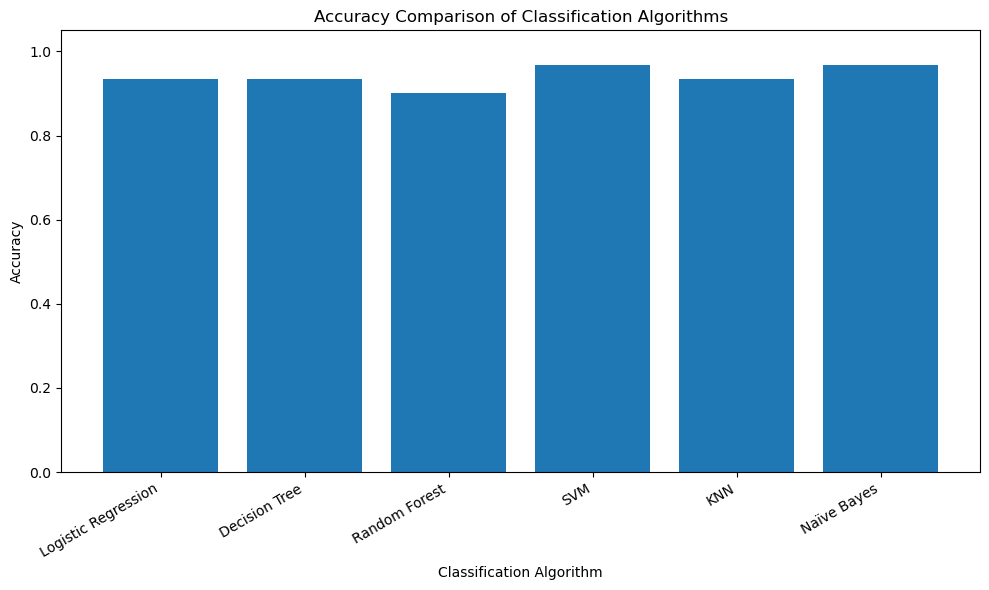

In [69]:
# Compare the accuracy of all classification algorithms

plt.figure(figsize=(10, 6))

plt.bar(
    results["Algorithm"],
    results["Accuracy"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Algorithms")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

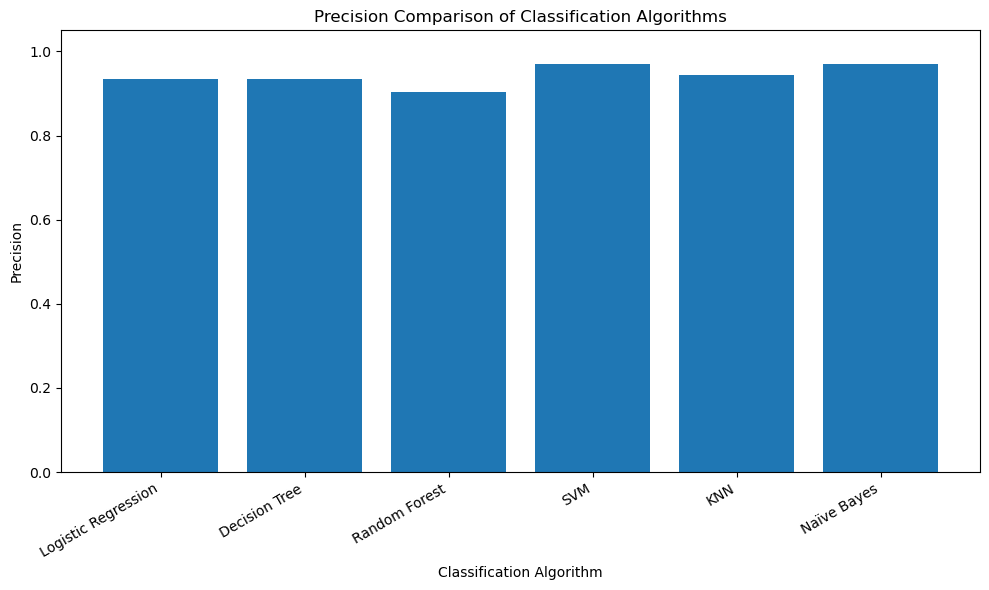

In [70]:
# Compare the precision of all classification algorithms

plt.figure(figsize=(10, 6))

plt.bar(
    results["Algorithm"],
    results["Precision"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("Precision")
plt.title("Precision Comparison of Classification Algorithms")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

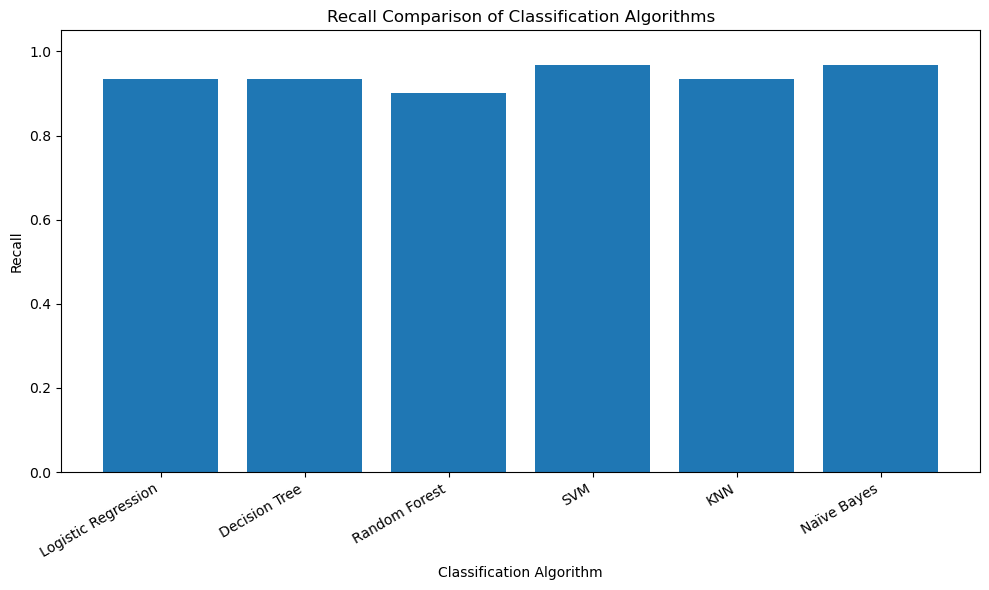

In [71]:
# Compare the recall of all classification algorithms

plt.figure(figsize=(10, 6))

plt.bar(
    results["Algorithm"],
    results["Recall"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("Recall")
plt.title("Recall Comparison of Classification Algorithms")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

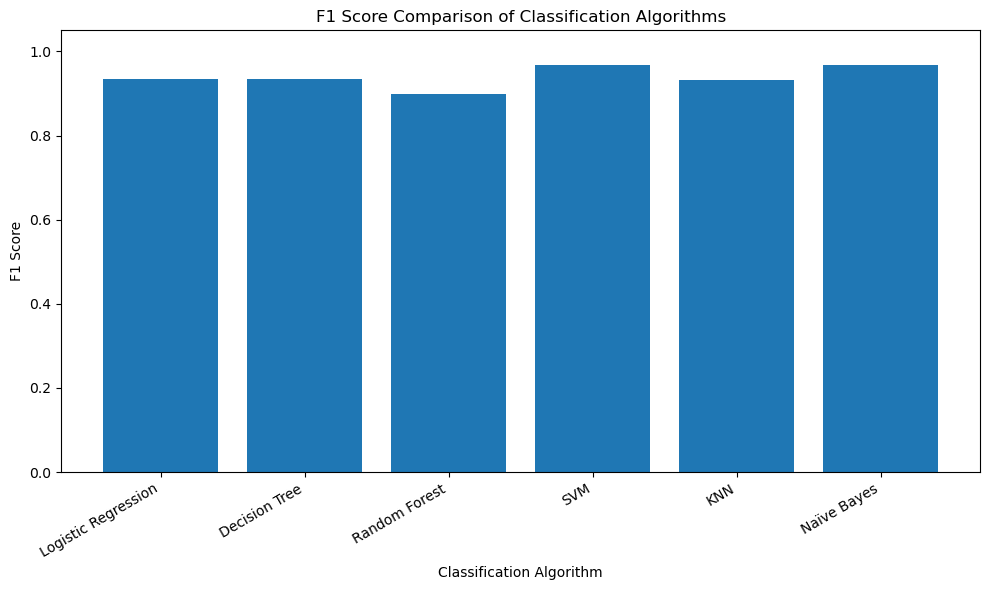

In [72]:
# Compare the F1 scores of all classification algorithms

plt.figure(figsize=(10, 6))

plt.bar(
    results["Algorithm"],
    results["F1 Score"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison of Classification Algorithms")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

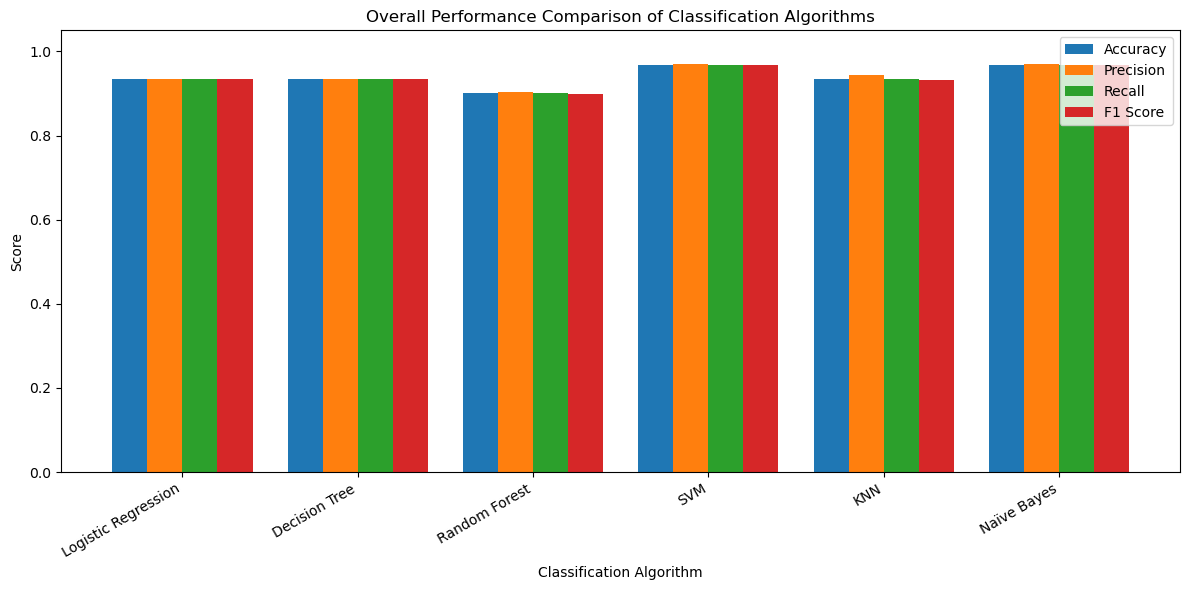

In [73]:
# Compare Accuracy, Precision, Recall and F1 Score together

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(results["Algorithm"]))
width = 0.2

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        results[metric],
        width,
        label=metric
    )

plt.xlabel("Classification Algorithm")
plt.ylabel("Score")
plt.title("Overall Performance Comparison of Classification Algorithms")

plt.xticks(
    x + width * 1.5,
    results["Algorithm"],
    rotation=30,
    ha="right"
)

plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()
plt.show()

In [74]:
# Store predictions of all classifiers for confusion matrix analysis

predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred,
    "SVM": svm_pred,
    "KNN": knn_pred,
    "Naïve Bayes": naive_bayes_pred
}

print("Predictions stored successfully.")

Predictions stored successfully.


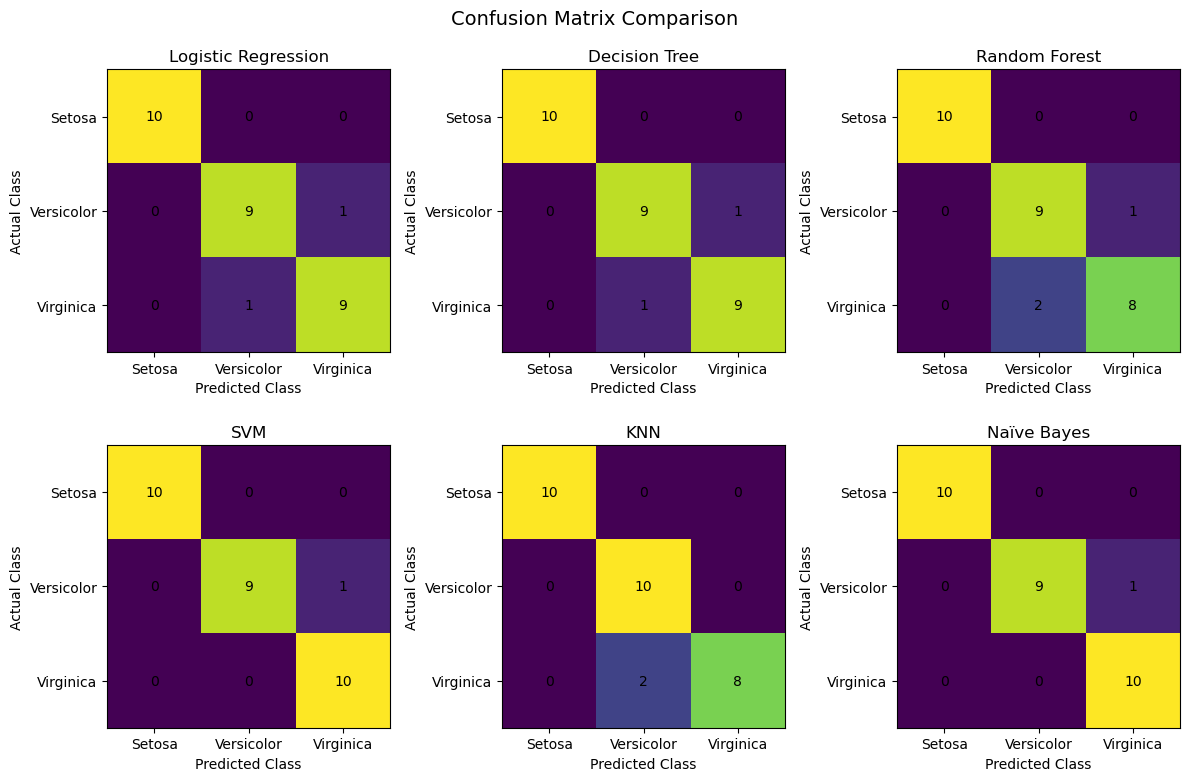

In [75]:
# Display confusion matrices for all classification algorithms

class_names = label_encoder.classes_

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

for ax, (model_name, prediction) in zip(
    axes.ravel(),
    predictions.items()
):
    
    cm = confusion_matrix(
        y_test,
        prediction
    )
    
    ax.imshow(cm)
    
    ax.set_title(model_name)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")
    
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    
    ax.set_xticklabels(["Setosa", "Versicolor", "Virginica"])
    ax.set_yticklabels(["Setosa", "Versicolor", "Virginica"])
    
    for i in range(3):
        for j in range(3):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

plt.suptitle("Confusion Matrix Comparison", fontsize=14)

plt.tight_layout()
plt.show()

In [76]:
# Display the detailed classification report for the best classifier

best_model_name = best_classifier["Algorithm"]

best_prediction = predictions[best_model_name]

print("Best Classifier:", best_model_name)
print("\nDetailed Classification Report:\n")

print(
    classification_report(
        y_test,
        best_prediction,
        target_names=[
            "Iris-setosa",
            "Iris-versicolor",
            "Iris-virginica"
        ]
    )
)

Best Classifier: SVM

Detailed Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [78]:
# Predict the species of a new flower using the best classifier

new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
)

new_flower_scaled = scaler.transform(new_flower)

if best_model_name == "Logistic Regression":
    prediction = logistic_model.predict(new_flower_scaled)

elif best_model_name == "Decision Tree":
    prediction = decision_tree_model.predict(new_flower)

elif best_model_name == "Random Forest":
    prediction = random_forest_model.predict(new_flower)

elif best_model_name == "SVM":
    prediction = svm_model.predict(new_flower_scaled)

elif best_model_name == "KNN":
    prediction = knn_model.predict(new_flower_scaled)

else:
    prediction = naive_bayes_model.predict(new_flower)

predicted_species = label_encoder.inverse_transform(prediction)

print("New Flower Measurements:")
print("Sepal Length : 5.1 cm")
print("Sepal Width  : 3.5 cm")
print("Petal Length : 1.4 cm")
print("Petal Width  : 0.2 cm")

print("\nPredicted Species:", predicted_species[0])

New Flower Measurements:
Sepal Length : 5.1 cm
Sepal Width  : 3.5 cm
Petal Length : 1.4 cm
Petal Width  : 0.2 cm

Predicted Species: setosa


In [79]:
# Display the final result of the classification experiment

print("=" * 65)
print("FINAL CLASSIFICATION EXPERIMENT RESULT")
print("=" * 65)

print("\nBest Algorithm :", best_classifier["Algorithm"])
print("Accuracy       :", round(best_classifier["Accuracy"], 4))
print("Precision      :", round(best_classifier["Precision"], 4))
print("Recall         :", round(best_classifier["Recall"], 4))
print("F1 Score       :", round(best_classifier["F1 Score"], 4))

FINAL CLASSIFICATION EXPERIMENT RESULT

Best Algorithm : SVM
Accuracy       : 0.9667
Precision      : 0.9697
Recall         : 0.9667
F1 Score       : 0.9666


Conclude!